Sentiment Analysis with NLP

---



In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import pandas as pd
import numpy as np
import string
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
df = pd.read_csv('/content/cleaned_reviews.csv')
df

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0
...,...,...,...,...
17335,positive,i love this speaker and love can take it anywh...,30,5.0
17336,positive,i use it in my house easy to connect and loud ...,13,4.0
17337,positive,the bass is good and the battery is amazing mu...,41,5.0
17338,positive,love it,2,5.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17340 non-null  object 
 1   cleaned_review         17337 non-null  object 
 2   cleaned_review_length  17340 non-null  int64  
 3   review_score           17340 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 542.0+ KB


In [ ]:
df.describe()

,cleaned_review_length,review_score
count,17340.000000,17340.000000
mean,30.300461,3.649077
std,35.836540,1.673500
min,0.000000,1.000000
25%,9.000000,2.000000
50%,20.000000,5.000000
75%,38.000000,5.000000
max,571.000000,5.000000


In [ ]:
df.isnull().sum()

,0
sentiments,0
cleaned_review,0
cleaned_review_length,0
review_score,0
processed_review,0


 Text Preprocessing and
 Initialize NLP tools

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

Lemmatizer Example

In [ ]:
print(lemmatizer.lemmatize("running",))
print(lemmatizer.lemmatize("running", pos="v"))
print(lemmatizer.lemmatize("better", pos="a"))
print(lemmatizer.lemmatize("mice"))

running
run
good
mouse


List of stopwords

In [ ]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'just', 'off', 'its', 'we', 'hadn', 'these', 'or', 'he', 'are', 'me', 're', "wasn't", "hadn't", "doesn't", 'from', 'on', 'above', 'her', 'this', 'of', 'ourselves', 'haven', 'only', 'do', 'if', 'then', 'about', "mustn't", 'but', 'below', 'up', "don't", 'she', 'yourselves', 'myself', 'isn', "should've", 'at', 'ain', 'it', 'were', "mightn't", 'aren', 'having', "that'll", 'when', 'had', 'was', 'themselves', 'will', 'his', 'other', 'nor', 'needn', 'same', 'between', 'doesn', 'be', "you'd", 'has', 'until', 'am', 'down', "needn't", 'an', 'them', 'shan', 'most', 'won', 'here', 'i', 'whom', 'over', 'very', 'ours', 'how', 'll', 'with', 'in', "weren't", 'your', 'there', "aren't", "it's", 'any', 's', 'didn', 'why', 'him', 'yourself', 'both', 'wouldn', 'all', 'yours', 'too', 'hasn', 'for', 'doing', 'each', 'our', 'a', 'mightn', 'did', "didn't", "won't", 'herself', 'into', "wouldn't", 'm', 'few', 'ma', 'which', 'where', "hasn't", 'who', 'own', 'd', 'by', "haven't", 'while', "isn't", 'o', 'can', 'my

Example of Stopword

In [ ]:
sentence = "This is a beautiful day"
words = sentence.split()

filtered_words = [word for word in words if word.lower() not in stop_words]
print(filtered_words)

['beautiful', 'day']


In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) #Regular Expressions(!,@...) without word and space
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

In [ ]:
df['processed_review'] = df['cleaned_review'].apply(preprocess_text)

TF-IDF (Term Frequency-Inverse Document Frequency)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)  # Limiting to top 5000 words
X = vectorizer.fit_transform(df['processed_review'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(df['sentiments'])  # Convert categories to numbers (0, 1, 2)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])


Training Set Size: 13869
Testing Set Size: 3468


Training and Predicting with Naïve Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Evaluate the Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))


Model Accuracy: 0.7050173010380623
Classification Report:
               precision    recall  f1-score   support

    negative       1.00      0.01      0.02       315
     neutral       0.63      0.56      0.59      1248
    positive       0.74      0.92      0.82      1905

    accuracy                           0.71      3468
   macro avg       0.79      0.49      0.48      3468
weighted avg       0.72      0.71      0.66      3468



<ipython-input-13-e3e6691a4c61>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['sentiments'], order=df['sentiments'].value_counts().index, palette="coolwarm")


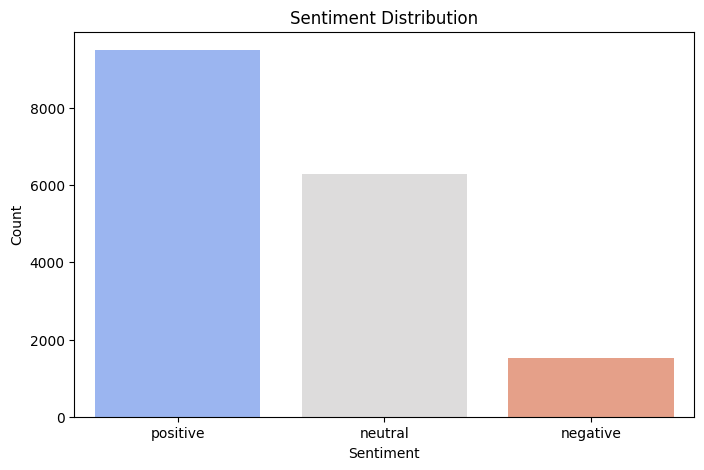

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x=df['sentiments'], order=df['sentiments'].value_counts().index, palette="coolwarm")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


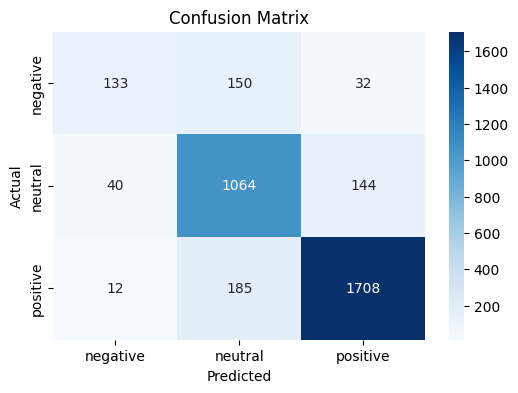

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
